# Feature Engineering Exploration

Explore spatial features, displacement features, and the novel hold usability score. Validate that features correlate with grade before modeling.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import seaborn as sns  # noqa: E402
from matplotlib.patches import FancyBboxPatch  # noqa: E402

from src.data.ingest import (  # noqa: E402
    BOARD_X_MAX,
    BOARD_X_MIN,
    BOARD_Y_MAX,
    BOARD_Y_MIN,
    load_climbs,
    load_difficulty_grades,
    load_placements,
)
from src.features.hold_usability import (  # noqa: E402
    ANGLE_BIN_LABELS,
    HOLD_USABILITY_FEATURE_COLS,
    aggregate_angle_conditioned_features,
    aggregate_hold_usability_features,
    aggregate_role_typical_grade_features,
    compute_hold_usability,
    compute_hold_usability_by_angle,
    compute_role_typical_grade,
)
from src.features.spatial import SPATIAL_FEATURE_COLS, extract_spatial_features  # noqa: E402

sns.set_theme(style="whitegrid", palette="viridis")
DB_PATH = "../data/raw/kilter.db"
grades_map = load_difficulty_grades(DB_PATH)
grade_labels = grades_map.set_index("difficulty")["boulder_name"].to_dict()

# V-grade tick helpers
vg_ticks = [t for t in sorted(grade_labels.keys()) if t % 2 == 0]
vg_tick_labels = [grade_labels[t].split("/")[1] for t in vg_ticks]


def draw_board(ax, placements_df, board_color="#e8e8e8", bolt_color="#cccccc"):
    """Draw a Kilter Board background with hold bolt positions."""
    board = FancyBboxPatch(
        (BOARD_X_MIN - 8, BOARD_Y_MIN - 4),
        BOARD_X_MAX - BOARD_X_MIN + 16,
        BOARD_Y_MAX - BOARD_Y_MIN + 8,
        boxstyle="round,pad=3",
        facecolor=board_color,
        edgecolor="#bbbbbb",
        linewidth=1.5,
    )
    ax.add_patch(board)
    ax.scatter(
        placements_df["x"],
        placements_df["y"],
        c=bolt_color,
        s=12,
        alpha=0.4,
        zorder=1,
        marker="o",
    )
    ax.set_xlim(BOARD_X_MIN - 15, BOARD_X_MAX + 15)
    ax.set_ylim(BOARD_Y_MIN - 10, BOARD_Y_MAX + 10)
    ax.set_aspect("equal")
    ax.set_facecolor("white")
    return ax

In [2]:
# Load data and extract all features
climbs = load_climbs(DB_PATH, min_ascents=5)
placements = load_placements(DB_PATH)

print("Extracting spatial features...")
spatial = extract_spatial_features(climbs, placements)

print("Computing hold usability scores (hand-role only)...")
hold_scores = compute_hold_usability(climbs, placements)
usability = aggregate_hold_usability_features(climbs, hold_scores)

print("Computing angle-conditioned hold usability...")
hold_scores_by_angle = compute_hold_usability_by_angle(climbs, placements)
angle_features = aggregate_angle_conditioned_features(climbs, hold_scores_by_angle)

print("Computing start/finish typical grades by angle...")
role_scores = compute_role_typical_grade(climbs, placements)
role_features = aggregate_role_typical_grade_features(climbs, role_scores)

# Merge all feature sets into single matrix
features = (
    spatial.merge(usability, on="climb_uuid")
    .merge(angle_features, on="climb_uuid")
    .merge(role_features, on="climb_uuid")
)
all_feature_cols = SPATIAL_FEATURE_COLS + HOLD_USABILITY_FEATURE_COLS

print(f"Feature matrix: {features.shape[0]:,} routes × {len(all_feature_cols)} features")
print(f"NaN count: {features[all_feature_cols].isna().sum().sum()}")
features[all_feature_cols + ["grade"]].describe().round(2)

Extracting spatial features...
Computing hold usability scores (hand-role only)...
Computing angle-conditioned hold usability...
Computing start/finish typical grades by angle...
Feature matrix: 15,029,594 routes × 34 features
NaN count: 34549


,hold_count,start_x,start_y,finish_x,finish_y,x_range,y_range,convex_hull_area,hold_density,angle,...,max_hold_usability,hold_usability_range,avg_angle_sensitivity,pct_hard_holds,avg_hold_usability_at_angle,min_hold_usability_at_angle,max_hold_usability_at_angle,start_hold_typical_grade,finish_hold_typical_grade,grade
count,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,15029594.00,...,15029593.00,15029593.00,15029593.00,15029593.00,15029593.00,15029593.00,15029593.00,14998841.00,15025807.00,15029594.00
mean,14.26,71.72,51.14,75.37,149.17,66.30,134.94,5201.40,0.00,34.60,...,1.15,4.92,0.47,0.02,-1.40,-3.70,1.00,17.15,17.15,16.58
std,8.02,33.12,14.64,31.04,10.75,26.37,16.53,2338.24,0.00,17.57,...,1.63,1.70,0.07,0.06,1.51,1.80,1.66,2.90,2.52,4.17
min,2.00,0.00,4.00,0.00,4.00,0.00,8.00,0.00,0.00,0.00,...,-5.59,0.00,0.25,0.00,-7.30,-8.35,-6.30,10.39,10.10,10.00
25%,11.00,44.00,40.00,56.00,152.00,48.00,128.00,3632.00,0.00,20.00,...,0.02,3.74,0.44,0.00,-2.36,-4.41,-0.17,15.03,15.42,13.18
50%,13.00,72.00,48.00,72.00,152.00,64.00,144.00,4880.00,0.00,35.00,...,1.13,4.74,0.48,0.00,-1.37,-3.47,1.00,17.48,17.56,16.03
75%,15.00,100.00,60.00,96.00,152.00,80.00,148.00,6176.00,0.00,50.00,...,2.31,5.95,0.51,0.00,-0.33,-2.54,2.14,19.31,19.09,19.73
max,306.00,144.00,152.00,144.00,152.00,144.00,148.00,19280.00,0.05,70.00,...,6.89,14.35,0.63,1.00,5.07,3.33,6.89,25.95,25.25,31.00


## 1. Feature Correlation with Grade\n\nWhich features have the strongest linear relationship with route difficulty?

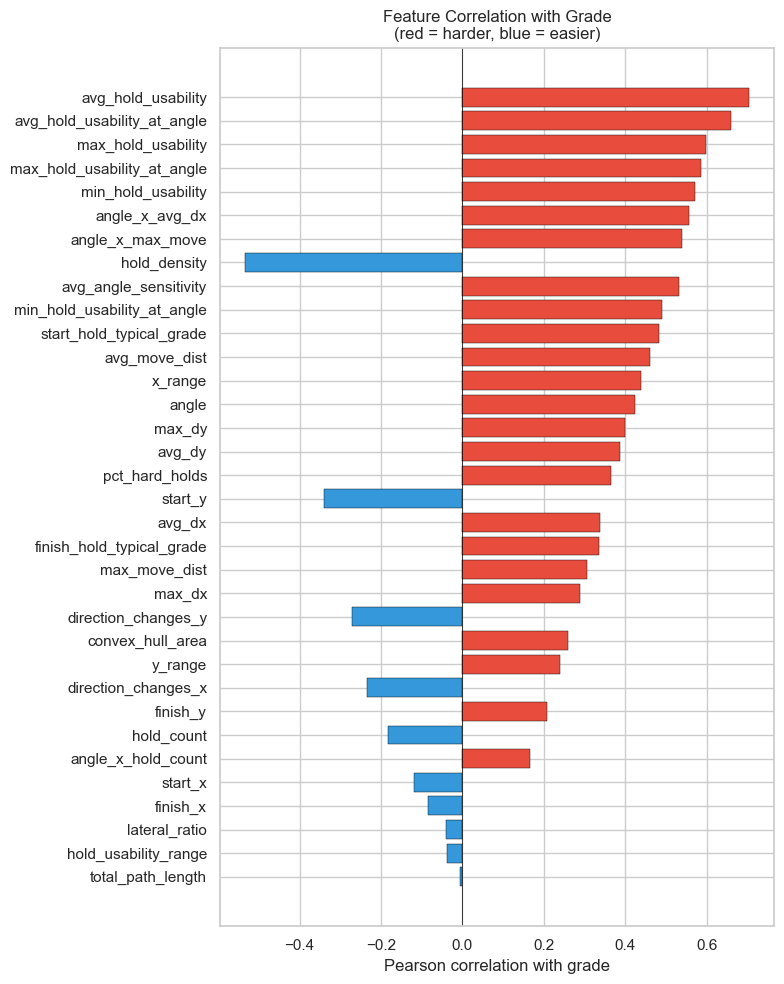

Top 10 features by |correlation| with grade:
  + avg_hold_usability: 0.703
  + avg_hold_usability_at_angle: 0.660
  + max_hold_usability: 0.597
  + max_hold_usability_at_angle: 0.586
  + min_hold_usability: 0.571
  + angle_x_avg_dx: 0.556
  + angle_x_max_move: 0.538
  - hold_density: -0.533
  + avg_angle_sensitivity: 0.532
  + min_hold_usability_at_angle: 0.489


In [3]:
# Correlation with grade, sorted by absolute value
corr = features[all_feature_cols + ["grade"]].corr()["grade"].drop("grade")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_sorted]
ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor="black", linewidth=0.3)
ax.set_xlabel("Pearson correlation with grade")
ax.set_title("Feature Correlation with Grade\n(red = harder, blue = easier)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 10 features by |correlation| with grade:")
for feat, val in corr.abs().sort_values(ascending=False).head(10).items():
    direction = "+" if corr[feat] > 0 else "-"
    print(f"  {direction} {feat}: {corr[feat]:.3f}")

## 2. Feature Correlation Matrix

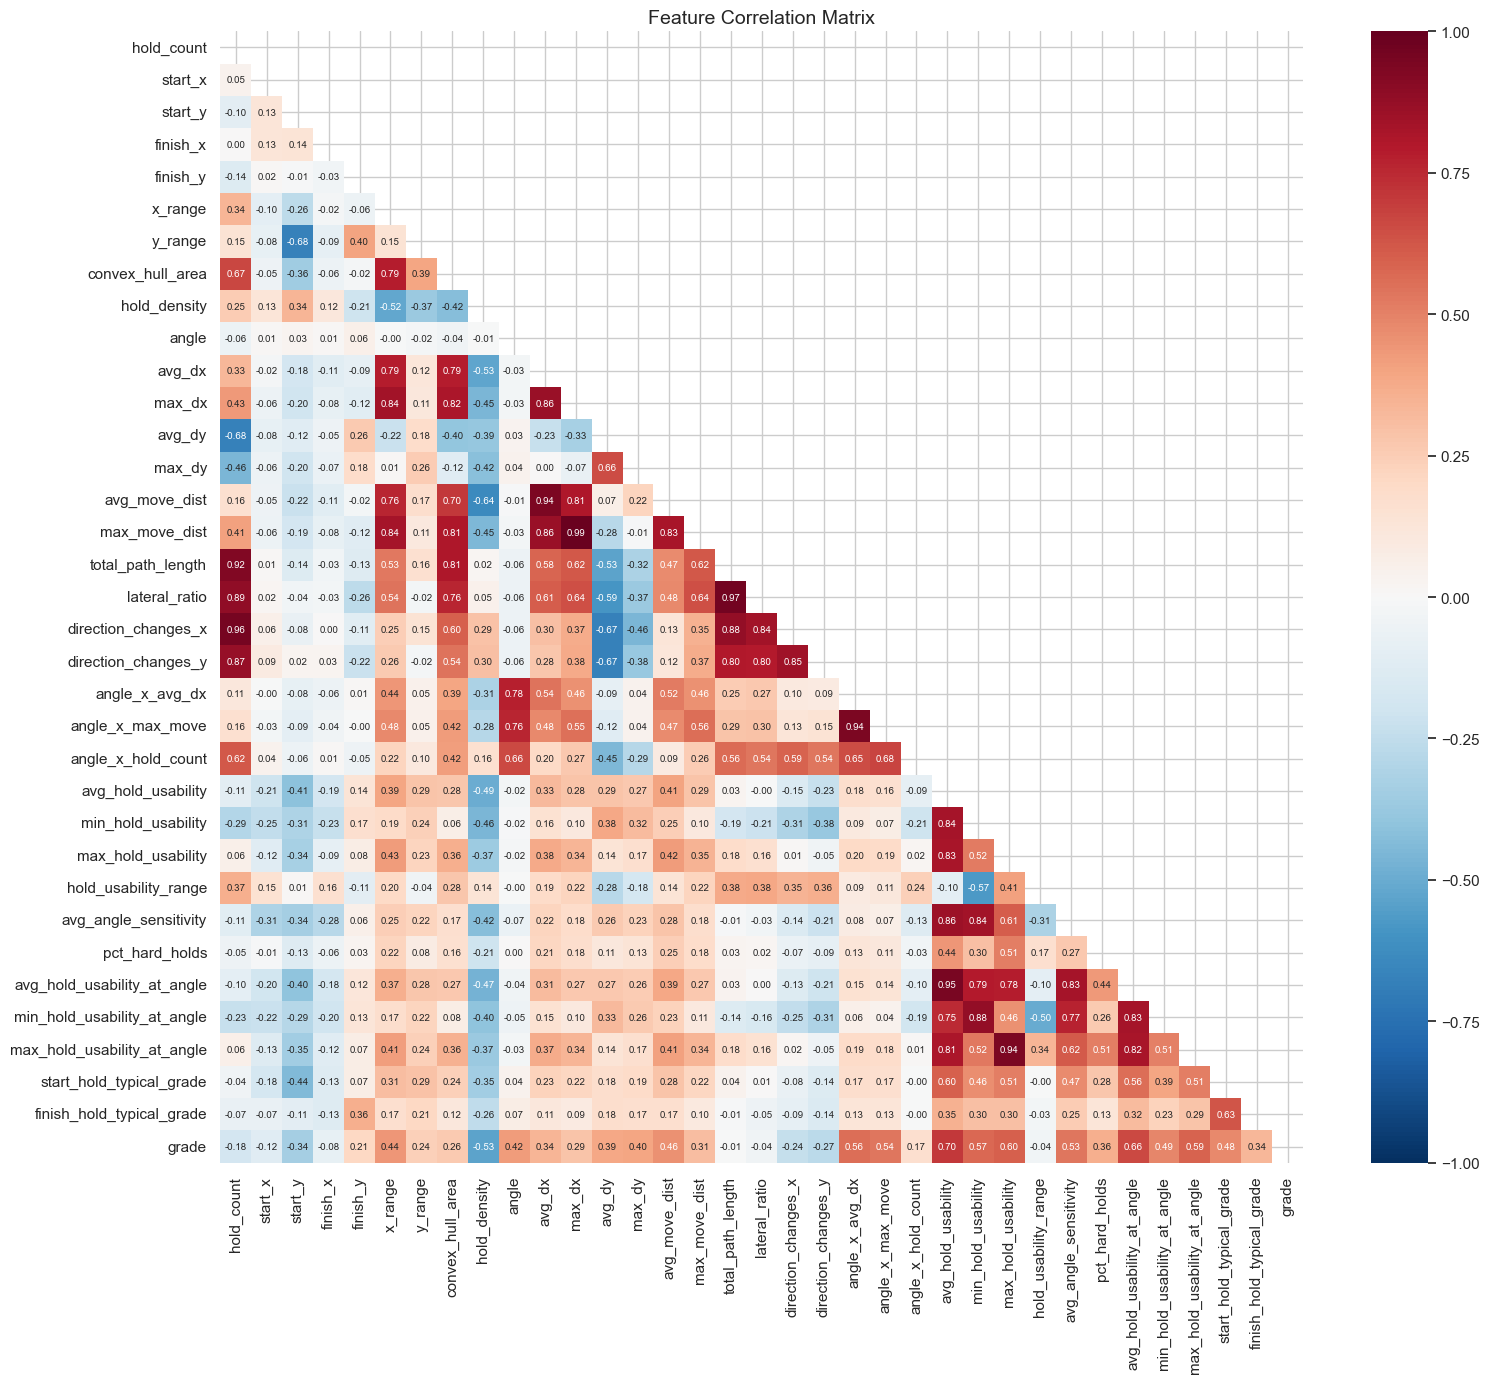

In [4]:
fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = features[all_feature_cols + ["grade"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Clustered Correlation Matrix

Hierarchical clustering groups features that carry similar information. Tight clusters suggest redundancy — useful for feature selection or understanding what the model "sees".

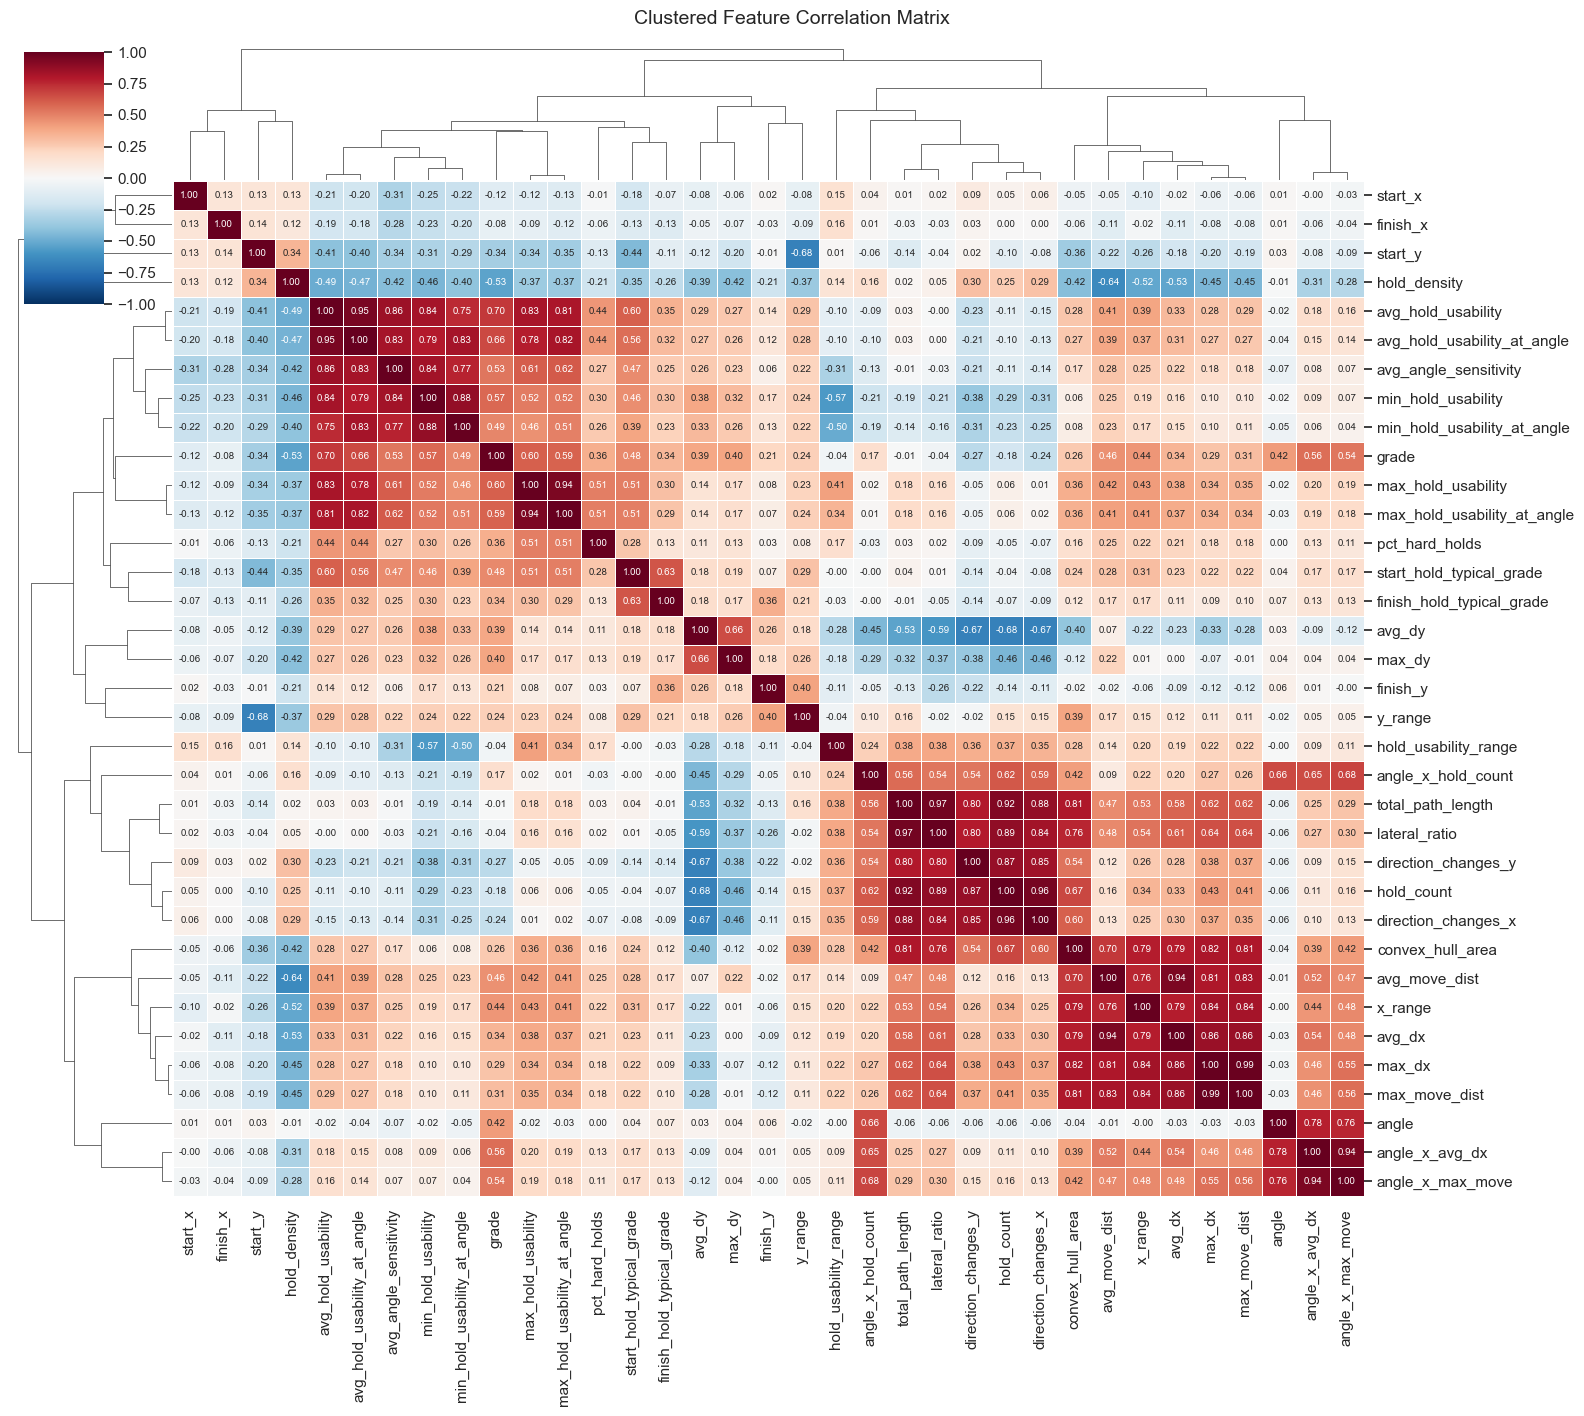

In [5]:
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(16, 14),
    annot_kws={"size": 7},
    linewidths=0.5,
    dendrogram_ratio=(0.12, 0.12),
)
g.fig.suptitle("Clustered Feature Correlation Matrix", fontsize=14, y=1.01)
plt.show()

## 3. Hold Usability Heatmap on Board\n\nThe novel derived feature: each hold's \"usability\" score based on the grades of routes it appears in. Green = easy hold (jug-like), red = hard hold (crimp-like).

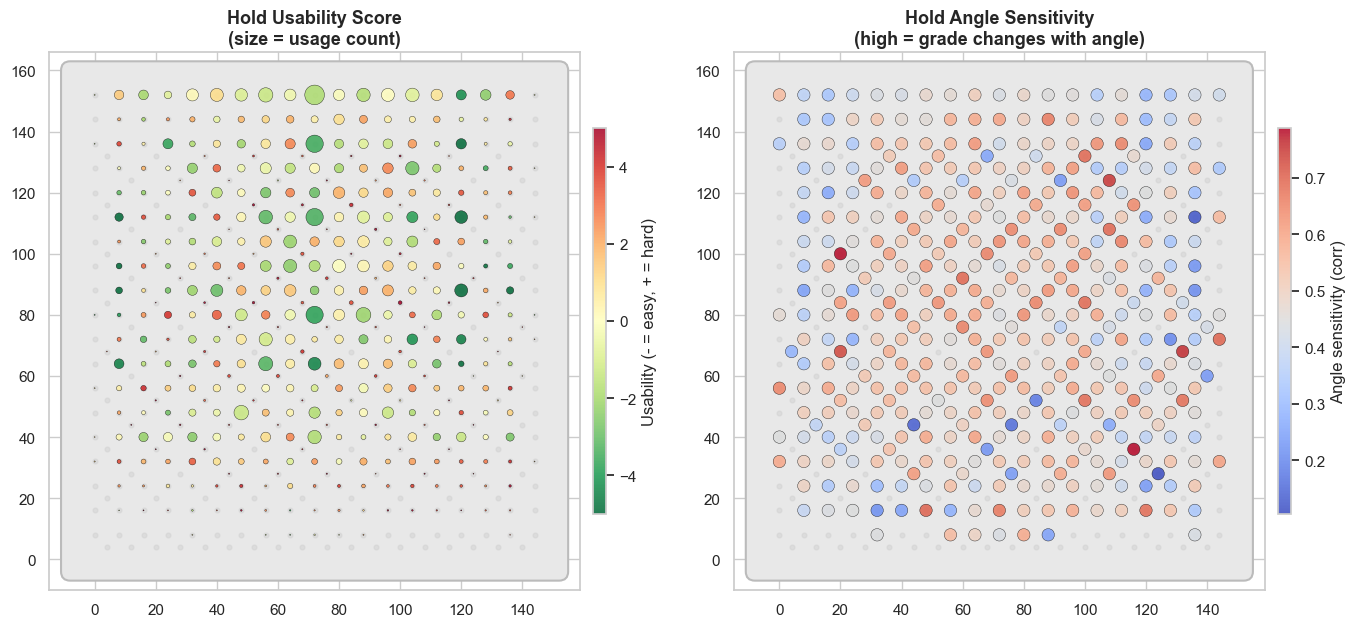

Hold usability range: -7.52 to 6.89
Mean angle sensitivity: 0.487


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Hold usability heatmap
draw_board(axes[0], placements)
scatter1 = axes[0].scatter(
    hold_scores["x"],
    hold_scores["y"],
    c=hold_scores["hold_usability"],
    s=hold_scores["hold_usage_count"] / hold_scores["hold_usage_count"].max() * 200,
    cmap="RdYlGn_r",
    vmin=-5,
    vmax=5,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
    zorder=2,
)
axes[0].set_title("Hold Usability Score\n(size = usage count)", fontsize=13, fontweight="bold")
cbar1 = plt.colorbar(scatter1, ax=axes[0], shrink=0.4, aspect=30, pad=0.02)
cbar1.set_label("Usability (- = easy, + = hard)")

# Hold angle sensitivity heatmap
draw_board(axes[1], placements)
scatter2 = axes[1].scatter(
    hold_scores["x"],
    hold_scores["y"],
    c=hold_scores["hold_angle_sensitivity"],
    s=80,
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
    zorder=2,
)
axes[1].set_title(
    "Hold Angle Sensitivity\n(high = grade changes with angle)",
    fontsize=13,
    fontweight="bold",
)
plt.colorbar(
    scatter2,
    ax=axes[1],
    label="Angle sensitivity (corr)",
    shrink=0.4,
    aspect=30,
    pad=0.02,
)

plt.tight_layout()
plt.show()

u_min = hold_scores["hold_usability"].min()
u_max = hold_scores["hold_usability"].max()
print(f"Hold usability range: {u_min:.2f} to {u_max:.2f}")
print(f"Mean angle sensitivity: {hold_scores['hold_angle_sensitivity'].mean():.3f}")

### Angle-Conditioned Hold Usability

Same hold, different difficulty depending on wall angle. Each panel shows hold usability computed only from routes within that angle range. Holds that lack sufficient data in a bin fall back to their global usability.

In [ ]:
# Merge angle-conditioned scores with placement coordinates for plotting
angle_scores_with_coords = hold_scores_by_angle.merge(
    placements[["placement_id", "x", "y"]], on="placement_id", how="left"
)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
angle_ranges = ["0-20deg", "20-35deg", "35-70deg"]

for ax, label, angle_range in zip(axes, ANGLE_BIN_LABELS, angle_ranges):
    col = f"hold_usability_{label}"
    draw_board(ax, placements)
    scatter = ax.scatter(
        angle_scores_with_coords["x"],
        angle_scores_with_coords["y"],
        c=angle_scores_with_coords[col],
        s=80,
        cmap="RdYlGn_r",
        vmin=-5,
        vmax=5,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.3,
        zorder=2,
    )
    ax.set_title(
        f"Hold Usability at {angle_range}\n({label} bin)",
        fontsize=13,
        fontweight="bold",
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.4, aspect=30, pad=0.02)
    cbar.set_label("Usability (- = easy, + = hard)")

plt.tight_layout()
plt.show()

# Show holds with largest usability change between low and steep angles
low = angle_scores_with_coords["hold_usability_low"]
steep = angle_scores_with_coords["hold_usability_steep"]
angle_scores_with_coords["usability_delta"] = steep - low
top_changers = angle_scores_with_coords.nlargest(10, "usability_delta")[
    ["placement_id", "x", "y", "hold_usability_low", "hold_usability_steep", "usability_delta"]
]
print("Top 10 holds most affected by angle (usability increases with steepness):")
print(top_changers.to_string(index=False))

### Start & Finish Hold Typical Grade by Angle

Each hold has a "typical grade" when used as a start or finish hold, computed per angle bin. This captures which holds are common starts/finishes at each difficulty level. For route generation: if you want a V3 at 30 degrees, pick holds whose typical start/finish grade is near V3 at the mid angle bin.

In [ ]:
# Merge role scores with coordinates for plotting
role_scores_with_coords = role_scores.merge(
    placements[["placement_id", "x", "y"]], on="placement_id", how="left"
)

# --- Start hold typical grade by angle ---
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
angle_ranges = ["0-20deg", "20-35deg", "35-70deg"]

for ax, label, angle_range in zip(axes, ANGLE_BIN_LABELS, angle_ranges):
    col = f"start_typical_grade_{label}"
    valid = role_scores_with_coords.dropna(subset=[col])
    draw_board(ax, placements)
    scatter = ax.scatter(
        valid["x"],
        valid["y"],
        c=valid[col],
        s=100,
        cmap="RdYlGn_r",
        vmin=10,
        vmax=28,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.3,
        zorder=2,
    )
    ax.set_title(
        f"Start Hold Typical Grade at {angle_range}",
        fontsize=13,
        fontweight="bold",
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.4, aspect=30, pad=0.02)
    cbar.set_ticks(vg_ticks[::2])
    cbar.set_ticklabels(vg_tick_labels[::2])
    cbar.set_label("Typical grade (V-scale)")

plt.suptitle(
    "Start Holds: What grade routes typically start here?",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- Finish hold typical grade by angle ---
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for ax, label, angle_range in zip(axes, ANGLE_BIN_LABELS, angle_ranges):
    col = f"finish_typical_grade_{label}"
    valid = role_scores_with_coords.dropna(subset=[col])
    draw_board(ax, placements)
    scatter = ax.scatter(
        valid["x"],
        valid["y"],
        c=valid[col],
        s=100,
        cmap="RdYlGn_r",
        vmin=10,
        vmax=28,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.3,
        zorder=2,
    )
    ax.set_title(
        f"Finish Hold Typical Grade at {angle_range}",
        fontsize=13,
        fontweight="bold",
    )
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.4, aspect=30, pad=0.02)
    cbar.set_ticks(vg_ticks[::2])
    cbar.set_ticklabels(vg_tick_labels[::2])
    cbar.set_label("Typical grade (V-scale)")

plt.suptitle(
    "Finish Holds: What grade routes typically finish here?",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Summary stats
for role_name in ["start", "finish"]:
    print(f"\n{role_name.title()} hold typical grade stats:")
    for label in ANGLE_BIN_LABELS:
        col = f"{role_name}_typical_grade_{label}"
        valid = role_scores_with_coords[col].dropna()
        print(
            f"  {label}: {len(valid)} holds, "
            f"range {valid.min():.1f}-{valid.max():.1f}, "
            f"mean {valid.mean():.1f}"
        )

## 4. Top Features vs Grade

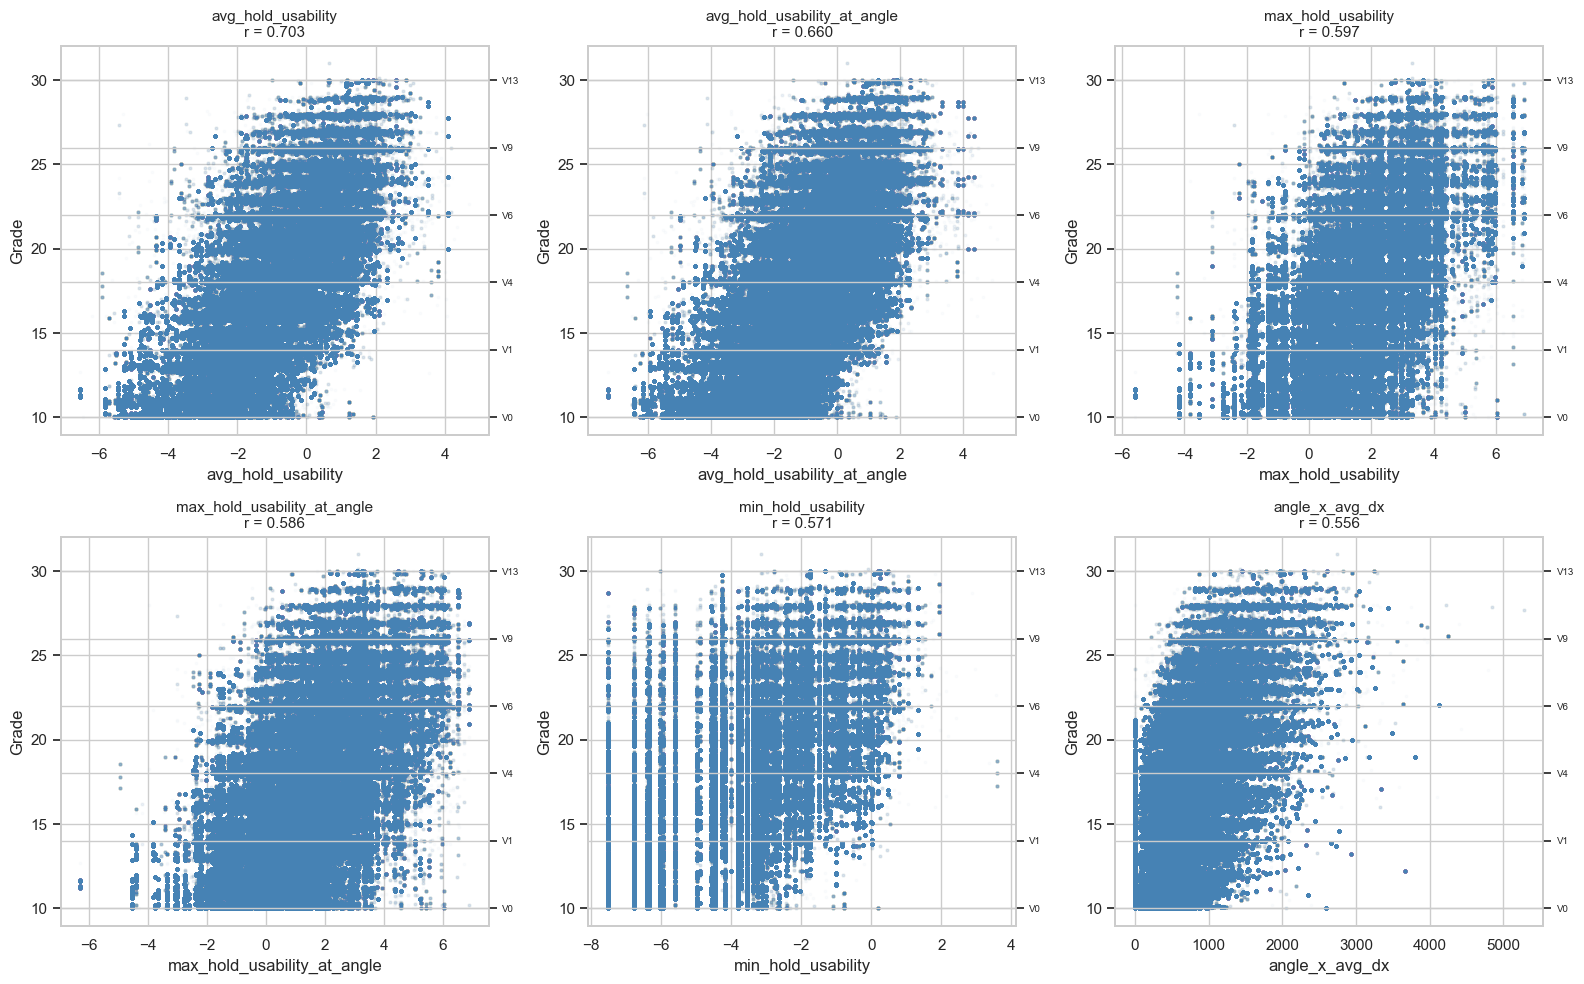

In [9]:
# Top 6 features by absolute correlation with grade
top_feats = corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flat, top_feats):
    ax.scatter(features[feat], features["grade"], alpha=0.02, s=3, color="steelblue")
    ax.set_xlabel(feat)
    ax.set_ylabel("Grade")
    r = corr[feat]
    ax.set_title(f"{feat}\nr = {r:.3f}", fontsize=11)
    # V-grade right axis
    ax_r = ax.twinx()
    ax_r.set_ylim(ax.get_ylim())
    ax_r.set_yticks(vg_ticks[::2])
    ax_r.set_yticklabels(vg_tick_labels[::2], fontsize=7)

plt.tight_layout()
plt.show()

## 5. Save Feature Matrix

In [ ]:
# Save combined feature matrix
features.to_parquet("../data/processed/features.parquet", index=False)
print(f"Saved features.parquet: {len(features):,} rows × {len(all_feature_cols)} features")

# Save per-hold usability scores
hold_scores.to_parquet("../data/processed/hold_usability.parquet", index=False)
print(f"Saved hold_usability.parquet: {len(hold_scores):,} holds")

# Save angle-conditioned hold usability scores
hold_scores_by_angle.to_parquet("../data/processed/hold_usability_by_angle.parquet", index=False)
print(f"Saved hold_usability_by_angle.parquet: {len(hold_scores_by_angle):,} holds")

# Save role-specific typical grade scores
role_scores.to_parquet("../data/processed/role_typical_grade.parquet", index=False)
print(f"Saved role_typical_grade.parquet: {len(role_scores):,} holds")